### Read data from csv

In [218]:
#pandas

import pandas as pd


#numpy
import numpy as np
from numpy import set_printoptions

#matplotlib
from matplotlib import pyplot as plt
%matplotlib inline


#seaborn
import seaborn as sns


#sklearn
from sklearn import metrics
from sklearn.linear_model import LogisticRegression  
from sklearn.metrics import classification_report,f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score

import pickle
import warnings
warnings.filterwarnings('ignore')
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [219]:
hypothyroid_df  = pd.read_csv('hypothyroid.csv')
# Checking the head of the set
hypothyroid_df.head()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41,F,f,f,f,f,f,f,f,f,...,t,125,t,1.14,t,109,f,?,SVHC,P
1,23,F,f,f,f,f,f,f,f,f,...,t,102,f,?,f,?,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109,t,0.91,t,120,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175,f,?,f,?,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61,t,0.87,t,70,f,?,SVI,P


In [220]:
# Checking the tail of the set
hypothyroid_df.tail()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
3767,30,F,f,f,f,f,f,f,f,f,...,f,?,f,?,f,?,f,?,other,P
3768,68,F,f,f,f,f,f,f,f,f,...,t,124,t,1.08,t,114,f,?,SVI,P
3769,74,F,f,f,f,f,f,f,f,f,...,t,112,t,1.07,t,105,f,?,other,P
3770,72,M,f,f,f,f,f,f,f,f,...,t,82,t,0.94,t,87,f,?,SVI,P
3771,64,F,f,f,f,f,f,f,f,f,...,t,99,t,1.07,t,92,f,?,other,P


In [221]:
# shape of the dataset
hypothyroid_df.shape

(3772, 30)

In [222]:
# size of the dataset
hypothyroid_df.size

113160

In [223]:
# Viewing the statistics of the data
hypothyroid_df.describe()

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
count,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772,...,3772,3772,3772,3772,3772,3772,3772,3772,3772,3772
unique,94,3,2,2,2,2,2,2,2,2,...,2,242,2,147,2,235,1,1,5,2
top,59,F,f,f,f,f,f,f,f,f,...,t,?,t,?,t,?,f,?,other,P
freq,95,2480,3308,3722,3729,3625,3719,3719,3713,3538,...,3541,231,3385,387,3387,385,3772,3772,2201,3481


In [224]:
# Checking information of the dataset
hypothyroid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3772 entries, 0 to 3771
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   age                        3772 non-null   object
 1   sex                        3772 non-null   object
 2   on thyroxine               3772 non-null   object
 3   query on thyroxine         3772 non-null   object
 4   on antithyroid medication  3772 non-null   object
 5   sick                       3772 non-null   object
 6   pregnant                   3772 non-null   object
 7   thyroid surgery            3772 non-null   object
 8   I131 treatment             3772 non-null   object
 9   query hypothyroid          3772 non-null   object
 10  query hyperthyroid         3772 non-null   object
 11  lithium                    3772 non-null   object
 12  goitre                     3772 non-null   object
 13  tumor                      3772 non-null   object
 14  hypopitu

In [225]:
# Checking for the data types
hypothyroid_df.dtypes

age                          object
sex                          object
on thyroxine                 object
query on thyroxine           object
on antithyroid medication    object
sick                         object
pregnant                     object
thyroid surgery              object
I131 treatment               object
query hypothyroid            object
query hyperthyroid           object
lithium                      object
goitre                       object
tumor                        object
hypopituitary                object
psych                        object
TSH measured                 object
TSH                          object
T3 measured                  object
T3                           object
TT4 measured                 object
TT4                          object
T4U measured                 object
T4U                          object
FTI measured                 object
FTI                          object
TBG measured                 object
TBG                         

### Data Cleaning

In [226]:
# Checking for unique values in all columns in the dataset
for uni in hypothyroid_df.columns:
#   print(hypothyroid_df.columns)
  print("\t")
  print(hypothyroid_df[uni].unique())


	
['41' '23' '46' '70' '18' '59' '80' '66' '68' '84' '67' '71' '28' '65'
 '42' '63' '51' '81' '54' '55' '60' '25' '73' '34' '78' '37' '85' '26'
 '58' '64' '44' '48' '61' '35' '83' '21' '87' '53' '77' '27' '69' '74'
 '38' '76' '45' '36' '22' '43' '72' '82' '31' '39' '49' '62' '57' '1' '50'
 '30' '29' '75' '19' '7' '79' '17' '24' '15' '32' '47' '16' '52' '33' '13'
 '10' '89' '56' '20' '90' '40' '88' '14' '86' '94' '12' '4' '11' '8' '5'
 '455' '2' '91' '6' '?' '93' '92']
	
['F' 'M' '?']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['f' 't']
	
['t' 'f']
	
['1.3' '4.1' '0.98' '0.16' '0.72' '0.03' '?' '2.2' '0.6' '2.4' '1.1' '2.8'
 '3.3' '12' '1.2' '1.5' '6' '2.1' '0.1' '0.8' '1.9' '3.1' '0.2' '13' '0.3'
 '0.035' '2.5' '0.5' '1.7' '7.3' '1.8' '0.26' '45' '5.4' '0.99' '0.25'
 '0.92' '0.15' '0.64' '1' '0.4' '2' '2.6' '14.8' '15' '19' '0.02' '3'
 '2.9' '3.2' '9' '1.6' '4.3' '0.005' '

In [227]:
# replace "?" with NAN 
hypothyroid_df = hypothyroid_df.replace({"?":np.NAN})


In [228]:
# convert object to float
hypothyroid_df[['age','TSH','T3','TT4','T4U','FTI', "TBG"]] = hypothyroid_df[['age','TSH','T3','TT4','T4U','FTI', "TBG"]].astype(float)
hypothyroid_df.dtypes


age                          float64
sex                           object
on thyroxine                  object
query on thyroxine            object
on antithyroid medication     object
sick                          object
pregnant                      object
thyroid surgery               object
I131 treatment                object
query hypothyroid             object
query hyperthyroid            object
lithium                       object
goitre                        object
tumor                         object
hypopituitary                 object
psych                         object
TSH measured                  object
TSH                          float64
T3 measured                   object
T3                           float64
TT4 measured                  object
TT4                          float64
T4U measured                  object
T4U                          float64
FTI measured                  object
FTI                          float64
TBG measured                  object
T

In [229]:
#handling missing values in the features 
hypothyroid_df.isnull().sum()

age                             1
sex                           150
on thyroxine                    0
query on thyroxine              0
on antithyroid medication       0
sick                            0
pregnant                        0
thyroid surgery                 0
I131 treatment                  0
query hypothyroid               0
query hyperthyroid              0
lithium                         0
goitre                          0
tumor                           0
hypopituitary                   0
psych                           0
TSH measured                    0
TSH                           369
T3 measured                     0
T3                            769
TT4 measured                    0
TT4                           231
T4U measured                    0
T4U                           387
FTI measured                    0
FTI                           385
TBG measured                    0
TBG                          3772
referral source                 0
binaryClass   

### Handling missing values

In [230]:
#fill the missing values with the mean
miss_cols = ['FTI','TSH','T3','TT4','T4U', 'TBG']
for i in miss_cols:
    hypothyroid_df[i] = hypothyroid_df[i].fillna(hypothyroid_df[i].mean())
hypothyroid_df

,age,sex,on thyroxine,query on thyroxine,on antithyroid medication,sick,pregnant,thyroid surgery,I131 treatment,query hypothyroid,...,TT4 measured,TT4,T4U measured,T4U,FTI measured,FTI,TBG measured,TBG,referral source,binaryClass
0,41.0,F,f,f,f,f,f,f,f,f,...,t,125.000000,t,1.140,t,109.000000,f,NaN,SVHC,P
1,23.0,F,f,f,f,f,f,f,f,f,...,t,102.000000,f,0.995,f,110.469649,f,NaN,other,P
2,46.0,M,f,f,f,f,f,f,f,f,...,t,109.000000,t,0.910,t,120.000000,f,NaN,other,P
3,70.0,F,t,f,f,f,f,f,f,f,...,t,175.000000,f,0.995,f,110.469649,f,NaN,other,P
4,70.0,F,f,f,f,f,f,f,f,f,...,t,61.000000,t,0.870,t,70.000000,f,NaN,SVI,P
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3767,30.0,F,f,f,f,f,f,f,f,f,...,f,108.319345,f,0.995,f,110.469649,f,NaN,other,P
3768,68.0,F,f,f,f,f,f,f,f,f,...,t,124.000000,t,1.080,t,114.000000,f,NaN,SVI,P
3769,74.0,F,f,f,f,f,f,f,f,f,...,t,112.000000,t,1.070,t,105.000000,f,NaN,other,P
3770,72.0,M,f,f,f,f,f,f,f,f,...,t,82.000000,t,0.940,t,87.000000,f,NaN,SVI,P


In [231]:
#fill age and sex column with mode imputation
hypothyroid_df['age'] = hypothyroid_df['age'].fillna(hypothyroid_df['age'].mode()[0])
hypothyroid_df['sex'] = hypothyroid_df['sex'].fillna(hypothyroid_df['sex'].mode()[0])
hypothyroid_df.isnull().sum()

age                             0
sex                             0
on thyroxine                    0
query on thyroxine              0
on antithyroid medication       0
sick                            0
pregnant                        0
thyroid surgery                 0
I131 treatment                  0
query hypothyroid               0
query hyperthyroid              0
lithium                         0
goitre                          0
tumor                           0
hypopituitary                   0
psych                           0
TSH measured                    0
TSH                             0
T3 measured                     0
T3                              0
TT4 measured                    0
TT4                             0
T4U measured                    0
T4U                             0
FTI measured                    0
FTI                             0
TBG measured                    0
TBG                          3772
referral source                 0
binaryClass   

In [232]:
# feature TBG will be removed because it has over 91% missing values
del hypothyroid_df["TBG"]

In [233]:
hypothyroid_df.isnull().sum()

age                          0
sex                          0
on thyroxine                 0
query on thyroxine           0
on antithyroid medication    0
sick                         0
pregnant                     0
thyroid surgery              0
I131 treatment               0
query hypothyroid            0
query hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH measured                 0
TSH                          0
T3 measured                  0
T3                           0
TT4 measured                 0
TT4                          0
T4U measured                 0
T4U                          0
FTI measured                 0
FTI                          0
TBG measured                 0
referral source              0
binaryClass                  0
dtype: int64

In [234]:
# checking sum of duplicates in the dataset
hypothyroid_df.duplicated().sum()

63

In [235]:
#dropping duplicates
hypothyroid_df = hypothyroid_df.drop_duplicates(keep=False)

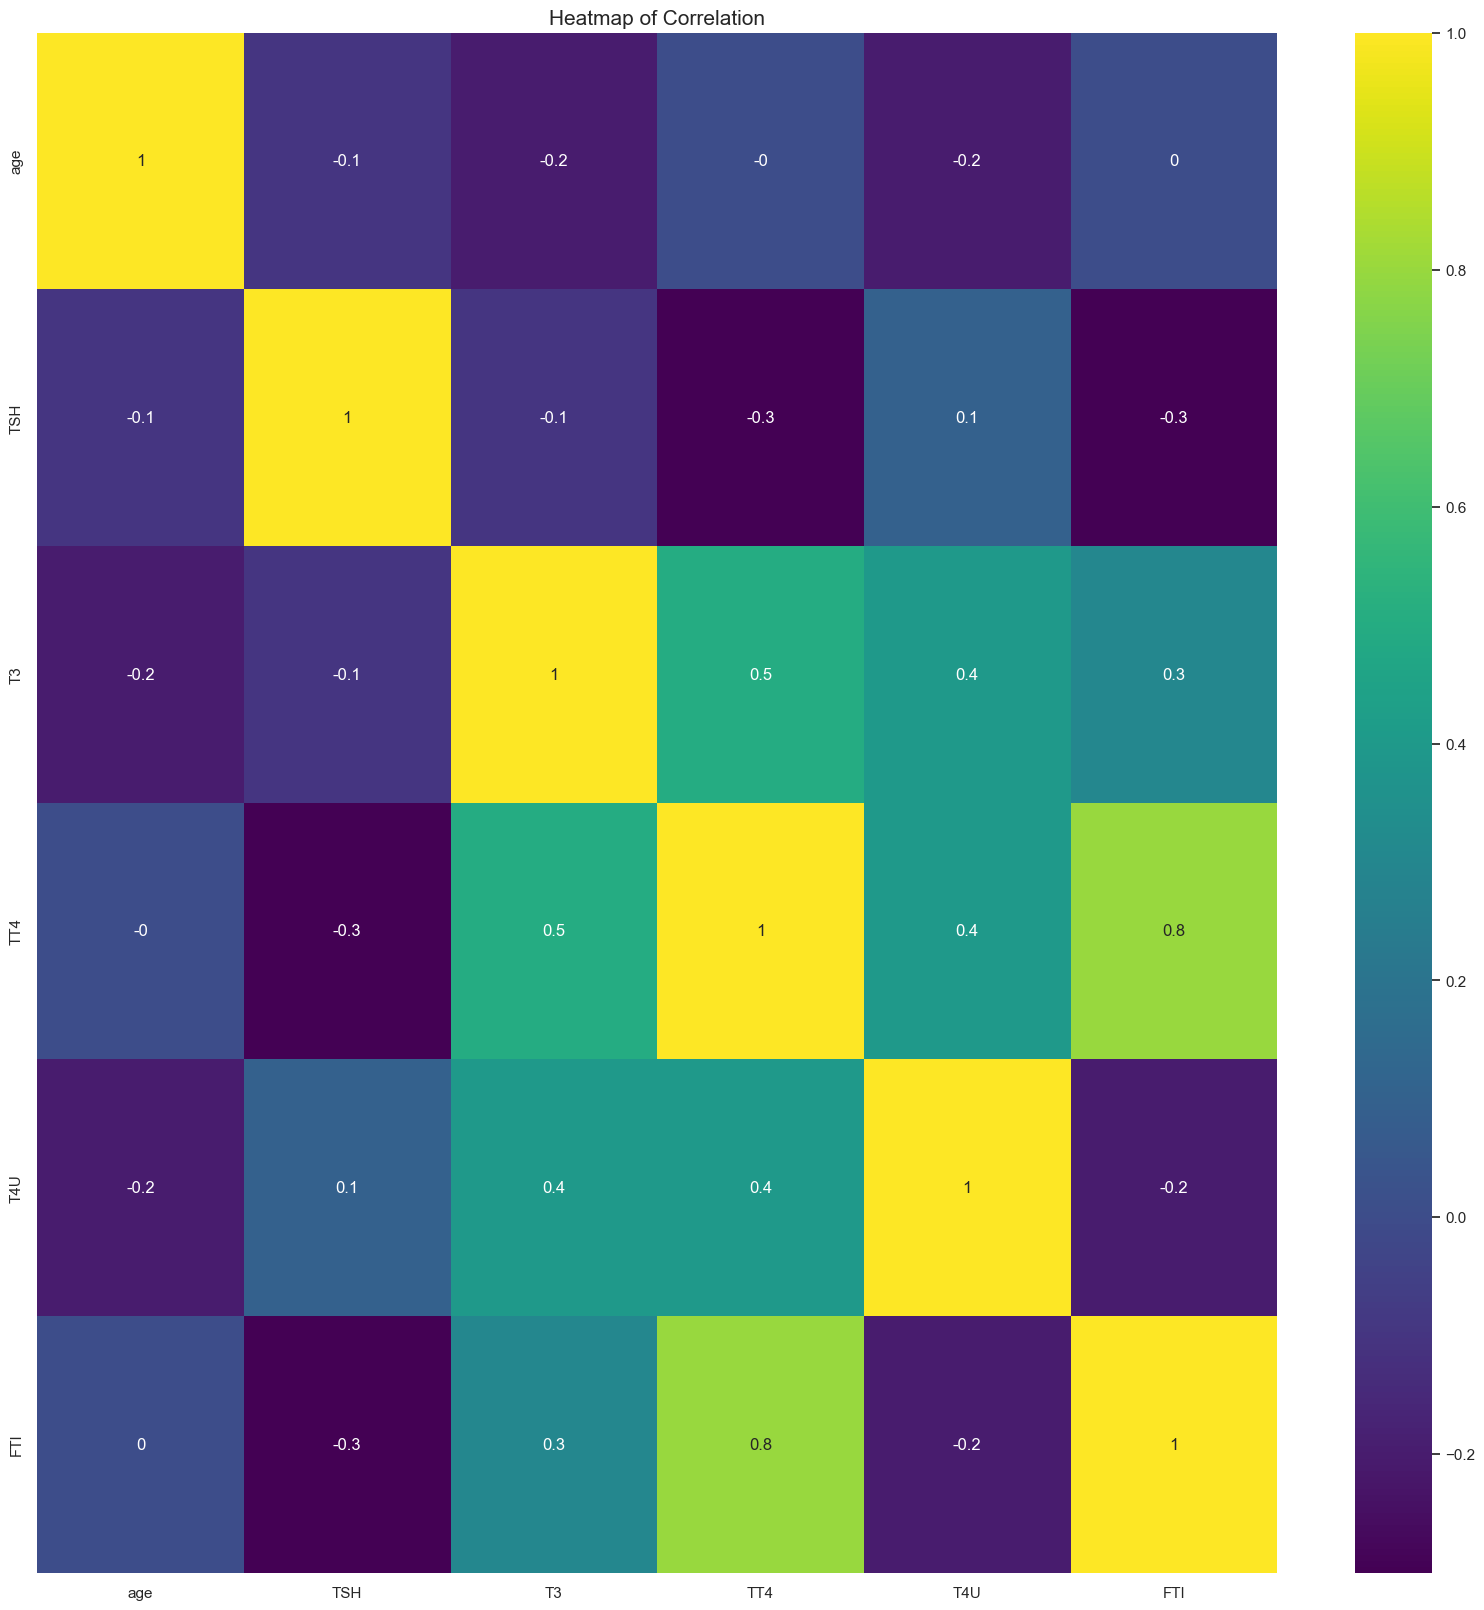

In [236]:
# Select only numeric columns
numeric_df = hypothyroid_df.select_dtypes(include=['number'])

# Set figure size before plotting
sns.set(rc={'figure.figsize': (20, 20)})

# Plot the heatmap
sns.heatmap(round(numeric_df.corr(), 1), annot=True, cmap='viridis')

plt.title('Heatmap of Correlation', fontsize=15)
plt.show()

In [237]:
# getting the features with more distinct elements and relation 
hypothyroid_df.nunique()

age                           93
sex                            2
on thyroxine                   2
query on thyroxine             2
on antithyroid medication      2
sick                           2
pregnant                       2
thyroid surgery                2
I131 treatment                 2
query hypothyroid              2
query hyperthyroid             2
lithium                        2
goitre                         2
tumor                          2
hypopituitary                  2
psych                          2
TSH measured                   2
TSH                          288
T3 measured                    2
T3                            70
TT4 measured                   2
TT4                          242
T4U measured                   2
T4U                          147
FTI measured                   2
FTI                          235
TBG measured                   1
referral source                5
binaryClass                    2
dtype: int64

## EDA

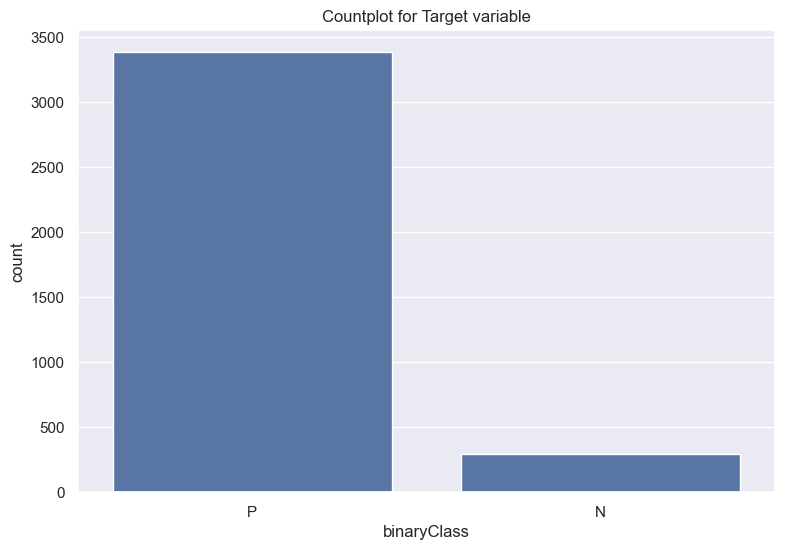

In [238]:
#displaying the count of target variable
plt.figure(figsize=(9,6))
sns.countplot(x='binaryClass',data=hypothyroid_df)
plt.title("Countplot for Target variable")
plt.show()

Text(0.5, 1.0, 'Distribution of Positive Class Based on Age')

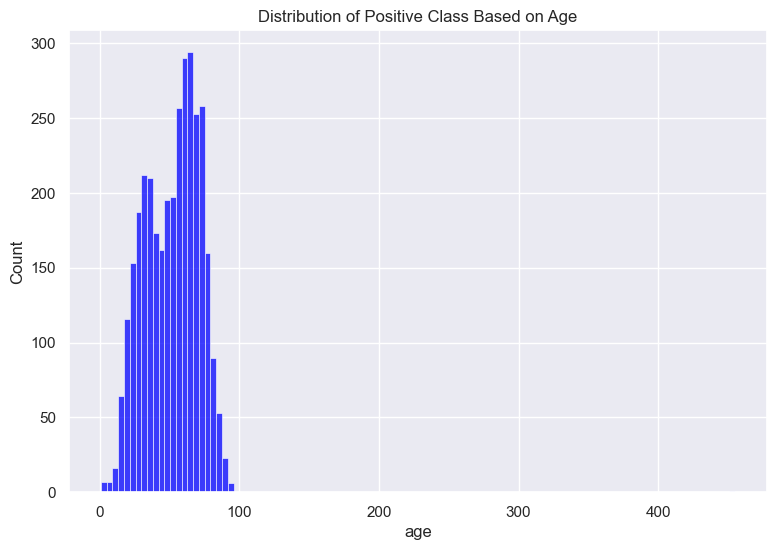

In [239]:
# distribution of positive class based on age
plt.figure(figsize=(9,6))
positive_thyroid_df = hypothyroid_df[hypothyroid_df.binaryClass == 'P']
sns.histplot(x = 'age',data = positive_thyroid_df, color='blue')
plt.title("Distribution of Positive Class Based on Age")

Text(0.5, 1.0, 'Distribution of negative Class Based on Age')

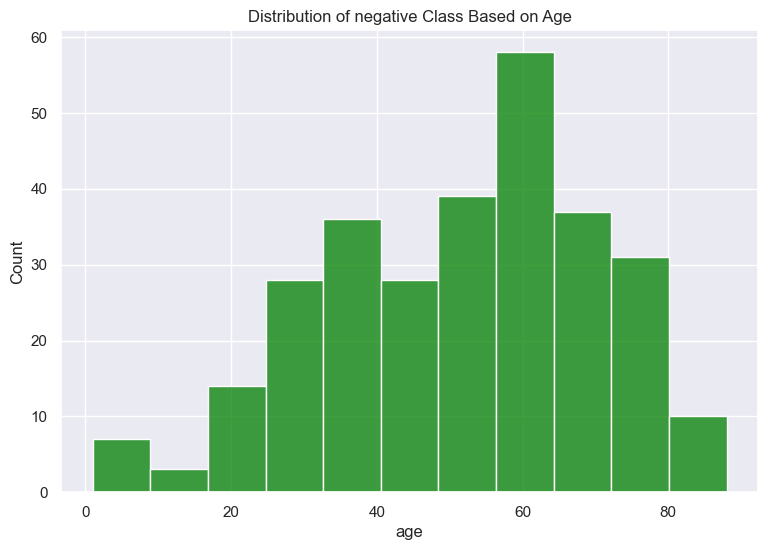

In [240]:
# distribution of negative class based on age
plt.figure(figsize=(9,6))
negative_thyroid_df = hypothyroid_df[hypothyroid_df.binaryClass == 'N']
sns.histplot(x = 'age',data = negative_thyroid_df, color='green')
plt.title("Distribution of negative Class Based on Age")


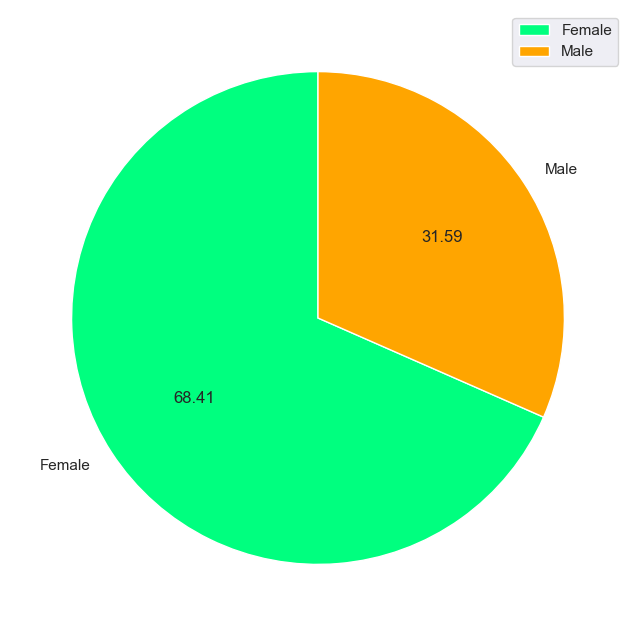

In [241]:
#Distribution of sex
plt.figure(figsize=(10,8))
plt.pie(x=positive_thyroid_df.sex.value_counts(),
        labels=['Female','Male'],
        startangle = 90,
        colors=['springgreen','orange'],
        autopct='%.2f'
       );
plt.legend()

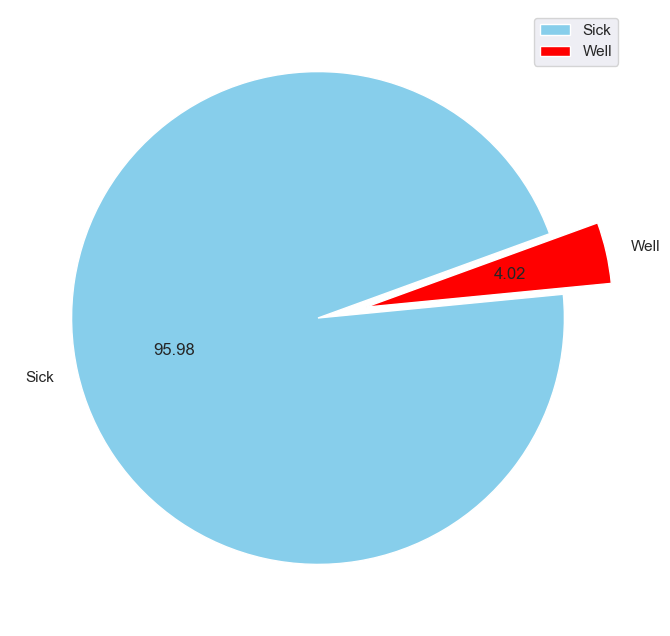

In [242]:
#distribution of sick against well 
plt.figure(figsize=(8,8))
plt.pie(x=positive_thyroid_df.sick.value_counts(),
        labels=['Sick','Well'],
        startangle = 20,
        colors=['skyblue','red'],
        autopct='%.2f',
        explode=[0,0.2]
       );
plt.legend();

<Axes: xlabel='T3', ylabel='Density'>

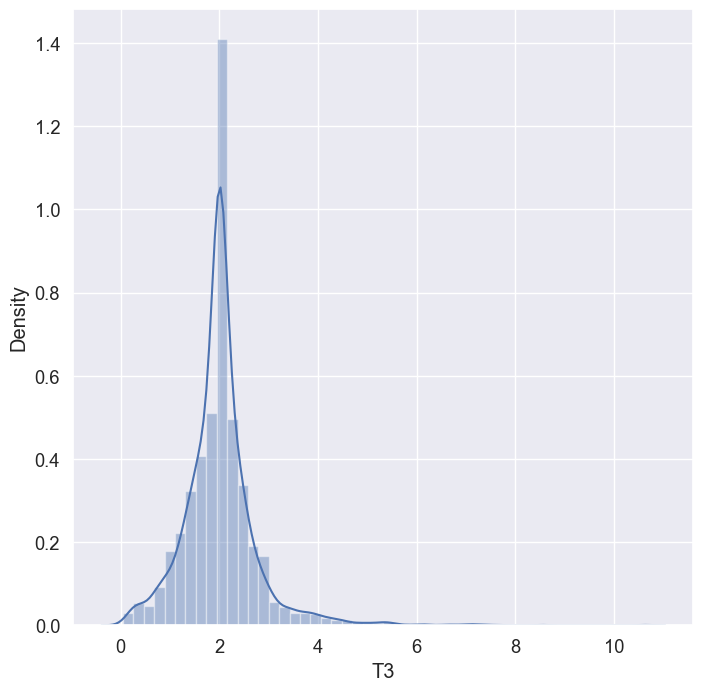

In [243]:
#distribution of T3
sns.set(rc={'figure.figsize': [8, 8]}, font_scale=1.2)
sns.distplot(hypothyroid_df['T3'])

<Axes: xlabel='TT4', ylabel='Density'>

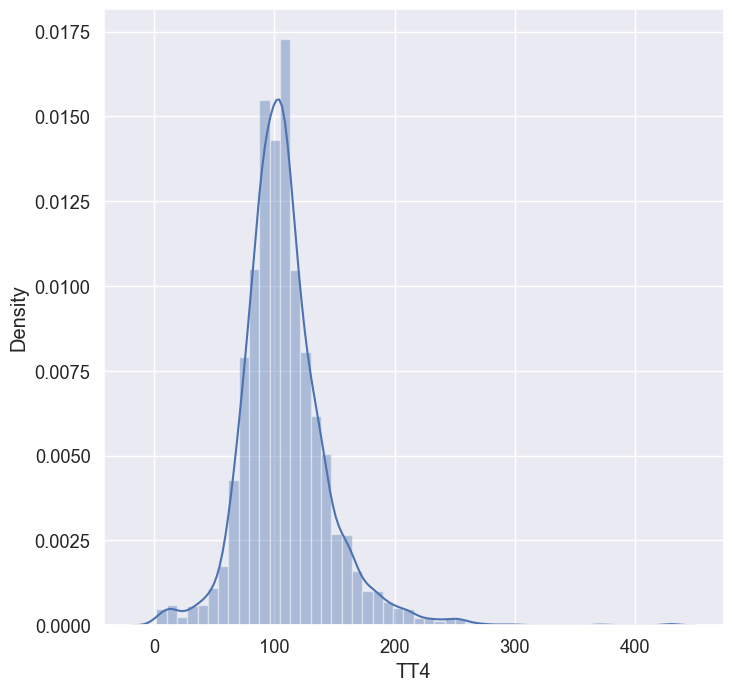

In [244]:
#distribution of TT4
sns.distplot(hypothyroid_df['TT4'])

<Axes: xlabel='T4U', ylabel='Density'>

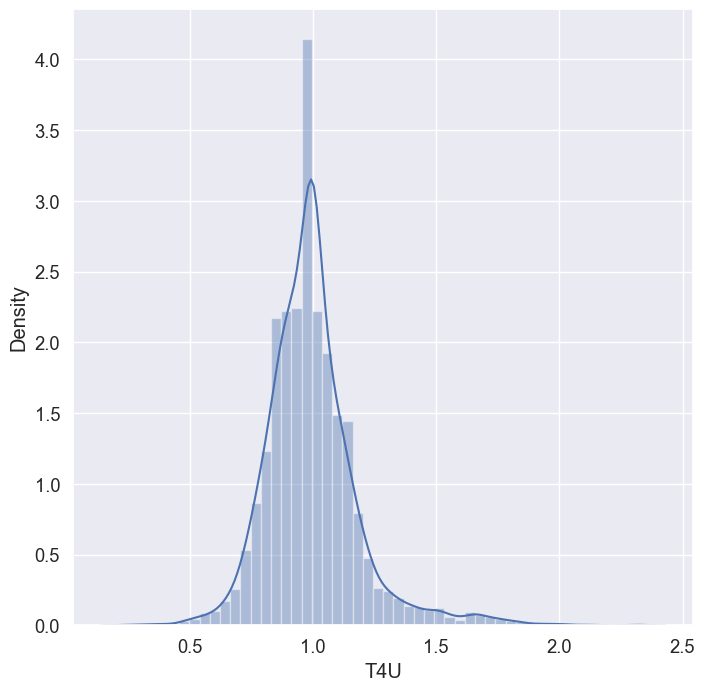

In [245]:
#distribution of T4U
sns.distplot(hypothyroid_df['T4U'])

<Axes: xlabel='FTI', ylabel='Density'>

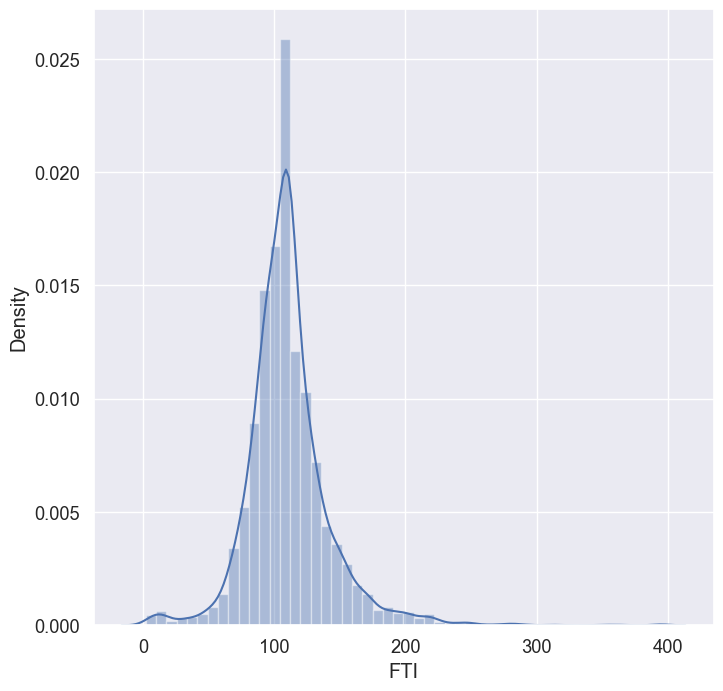

In [246]:
#distribution of FTI
sns.distplot(hypothyroid_df['FTI'])

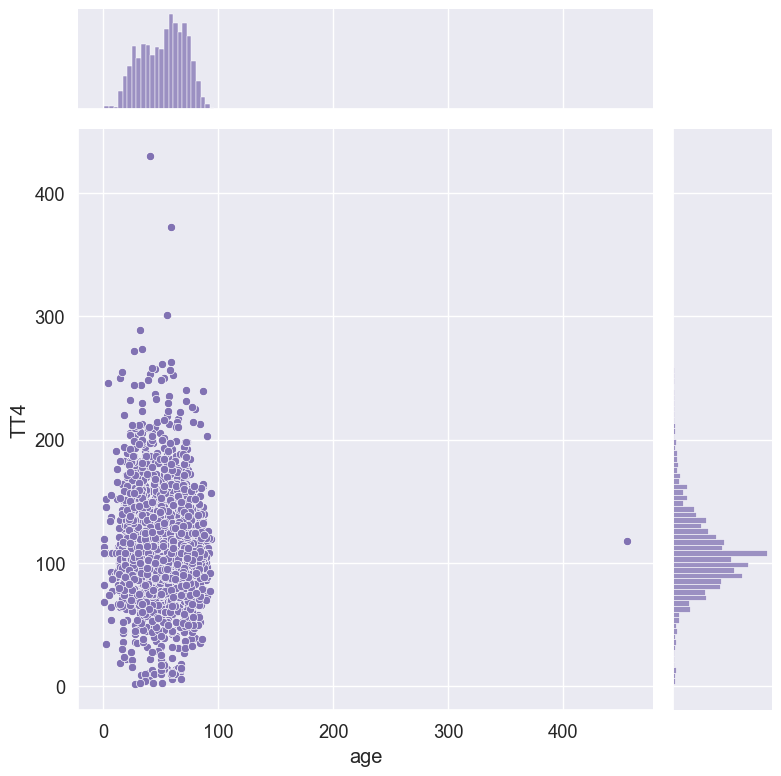

In [247]:
#distribution of age and TT4
sns.jointplot(x='age', y='TT4', data=hypothyroid_df, kind='scatter', height=8, color='m')

<Axes: xlabel='binaryClass', ylabel='count'>

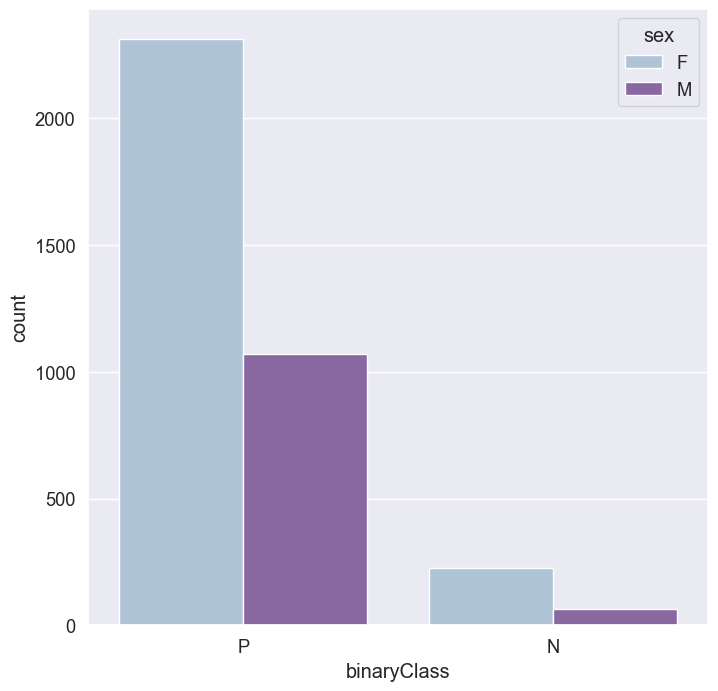

In [248]:
#distribution of dependent variable and sex
sns.countplot(x='binaryClass', data=hypothyroid_df, hue='sex', palette='BuPu')

In [249]:
df_encoded = hypothyroid_df.copy()

# Encode non-numeric columns
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

# Now get the correlation matrix
hypothyroid_df_corr = df_encoded.corr()

In [250]:
# 'referral source' into indicator columns of 0s and 1s (dummies)
hypothyroid_df = pd.get_dummies(hypothyroid_df, columns=['referral source'])

### Transform non-numerical labels to numerical labels.

In [251]:
#convert target variable to numeric
hypothyroid_df["binaryClass"] = hypothyroid_df["binaryClass"].replace({"P":1,"N":0})

In [252]:
#extracting independent variable
X = hypothyroid_df.drop('binaryClass',axis=1)

In [253]:
#extracting dependent variable
y = hypothyroid_df.binaryClass

In [254]:
#encoding the independent variable 
numerical_features = list()
categorical_features = list()
for column in X.columns:
    # In the dataset we only have float and int64.
    if (hypothyroid_df[column].dtype == 'float64' or hypothyroid_df[column].dtype == 'int64'):
        numerical_features.append(column)
    # Categorical
    elif (hypothyroid_df[column].dtype == 'object' or hypothyroid_df[column].dtype == 'bool'):
        categorical_features.append(column)
        
print('There are a total of {} numerical features in the dataset.'.format(len(numerical_features)))
print('There are a total of {} categorical features in the dataset.'.format(len(categorical_features)))

There are a total of 6 numerical features in the dataset.
There are a total of 26 categorical features in the dataset.


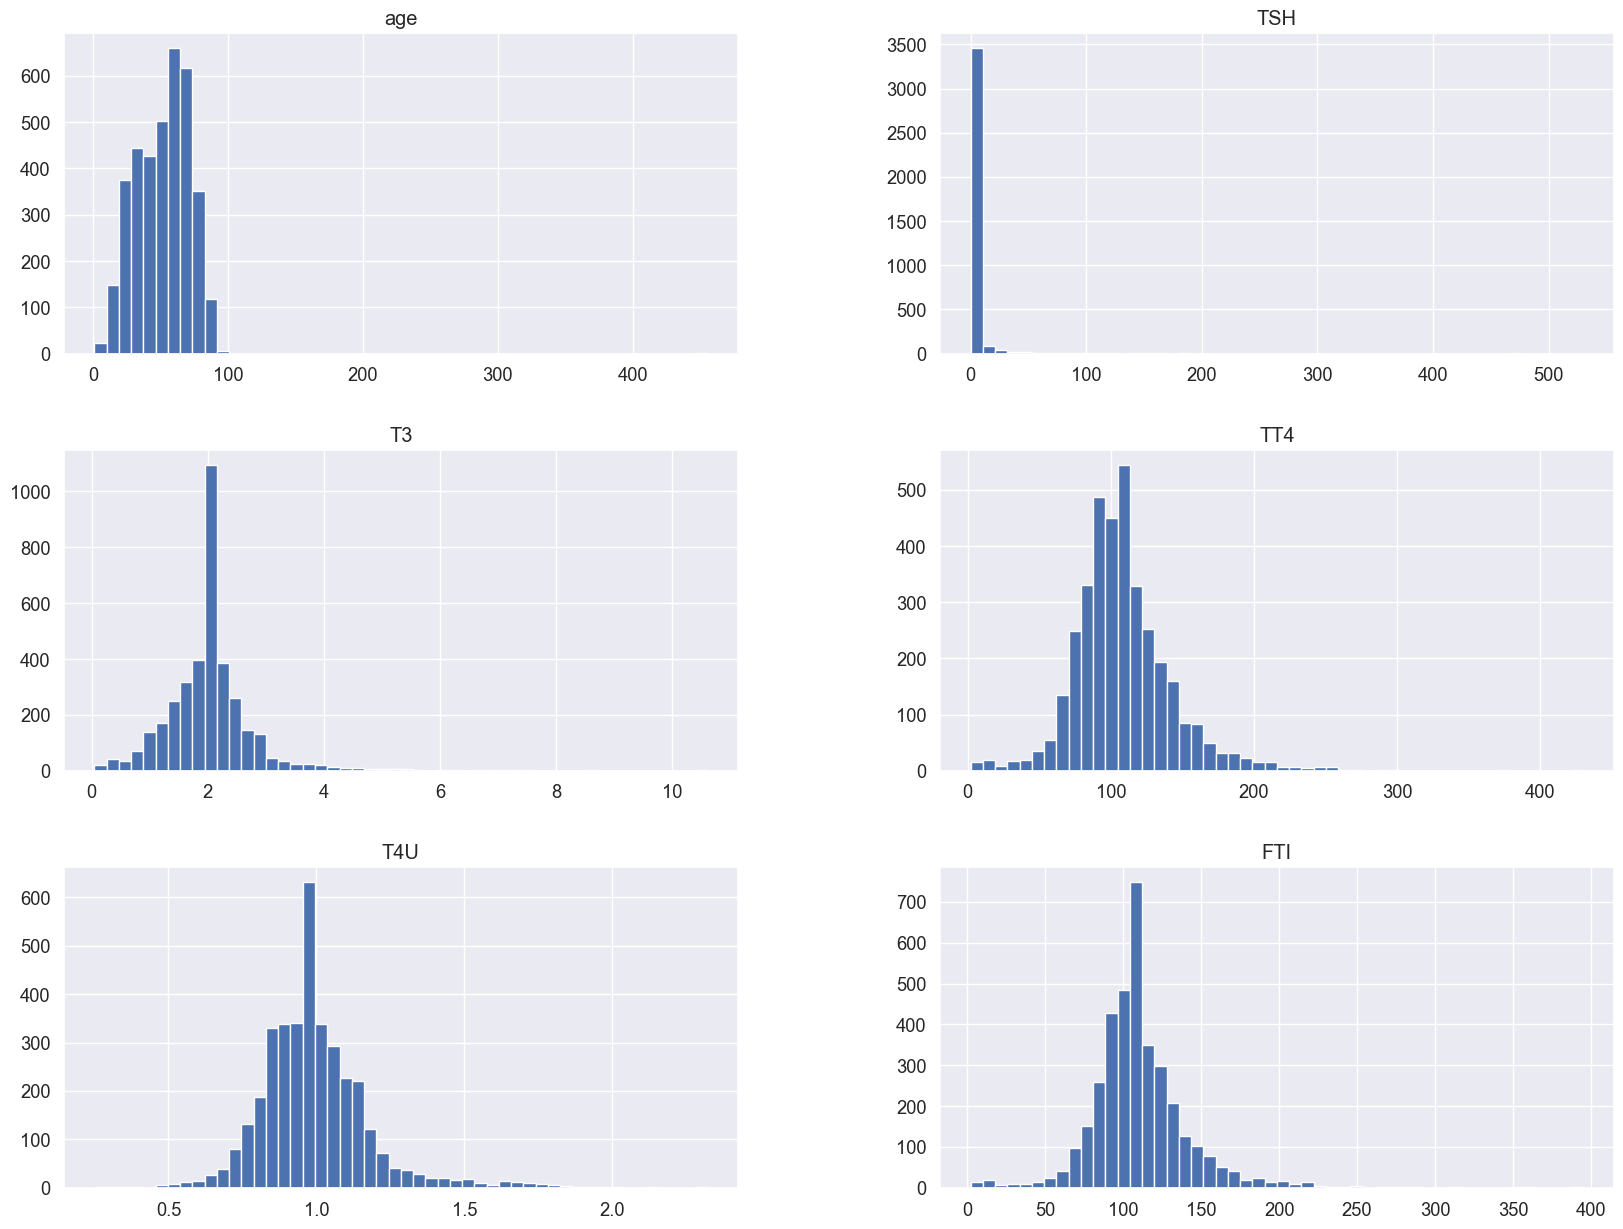

In [255]:
#visualization of numerical features
X_num_total = X[numerical_features]
X_num_total.hist(bins=50,figsize=(20, 15))
plt.show()

In [256]:
# categorical feature list
categorical_features_index = list()
# Encode categorical features, get the indexes of categorical 
for p in categorical_features:
    categorical_features_index.append(X.columns.get_loc(p))
    X[p] = LabelEncoder().fit_transform(X[p])

In [257]:
#encoding the dependent variable
labelencoder_y = LabelEncoder()  
y = labelencoder_y.fit_transform(y)

### Split original data into training data and testing data

In [258]:
#splitting the data to 80-20%
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state=11)  
len(X_train), len(X_test)

(2940, 735)

### Feature scaling or normalization

In [259]:
#standardize the independent variables of the dataset 
st_X= StandardScaler()  
X_train= st_X.fit_transform(X_train) 
len(X_train), len(y_train)

(2940, 2940)

In [260]:
#transforming the independent variable test
X_test= st_X.transform(X_test) 
X_test

array([[ 0.19584354, -0.67807192, -0.38001864, ..., -0.10323073,
        -0.62455658,  0.86843342],
       [-1.52275619, -0.67807192, -0.38001864, ..., -0.10323073,
        -0.62455658,  0.86843342],
       [ 0.24494639,  1.47476981, -0.38001864, ..., -0.10323073,
        -0.62455658,  0.86843342],
       ...,
       [ 1.52162048, -0.67807192, -0.38001864, ..., -0.10323073,
        -0.62455658,  0.86843342],
       [ 0.63776919, -0.67807192, -0.38001864, ..., -0.10323073,
        -0.62455658,  0.86843342],
       [ 0.53956349, -0.67807192, -0.38001864, ..., -0.10323073,
        -0.62455658,  0.86843342]])

## MODEL

### Fitting SVM to the Training set

In [261]:
# "Support vector classifier"  
classifier = SVC(kernel='linear', random_state=11)  
#training the model using training set
classifier.fit(X_train, y_train)  

SVC(kernel='linear', random_state=11)

In [262]:
# Predicting and training the Test Result
classifier_predict_train = classifier.predict(X_train)
classifier_predict_test= classifier.predict(X_test) 

In [263]:
from sklearn.metrics import accuracy_score
# checking the accuracy score of the test and train set
print('Prediction on training set', accuracy_score(classifier_predict_train, y_train))
print('Prediction on testing set', accuracy_score(classifier_predict_test, y_test))

Prediction on training set 0.9741496598639455
Prediction on testing set 0.9741496598639455


## Feature Selection

### Feature Importance

In [264]:
# feature extraction
FeatureImportance = classifier.coef_[0]
for i,d in enumerate(FeatureImportance):
    print('Feature: %0d, Score: %5f'%(i,d))

Feature: 0, Score: 0.017905
Feature: 1, Score: 0.009965
Feature: 2, Score: 1.890614
Feature: 3, Score: 0.034186
Feature: 4, Score: 0.026675
Feature: 5, Score: 0.005057
Feature: 6, Score: 0.000000
Feature: 7, Score: 1.759100
Feature: 8, Score: 0.005342
Feature: 9, Score: -0.065709
Feature: 10, Score: -0.000182
Feature: 11, Score: 0.011420
Feature: 12, Score: 0.008916
Feature: 13, Score: -0.055415
Feature: 14, Score: -0.000000
Feature: 15, Score: -0.012164
Feature: 16, Score: -0.192157
Feature: 17, Score: -4.387039
Feature: 18, Score: 0.053992
Feature: 19, Score: 0.124822
Feature: 20, Score: -0.027699
Feature: 21, Score: 0.252477
Feature: 22, Score: 0.008770
Feature: 23, Score: -0.055309
Feature: 24, Score: 0.008787
Feature: 25, Score: 0.027975
Feature: 26, Score: 0.000000
Feature: 27, Score: 0.053970
Feature: 28, Score: -0.032111
Feature: 29, Score: -0.006567
Feature: 30, Score: 0.033117
Feature: 31, Score: -0.026815


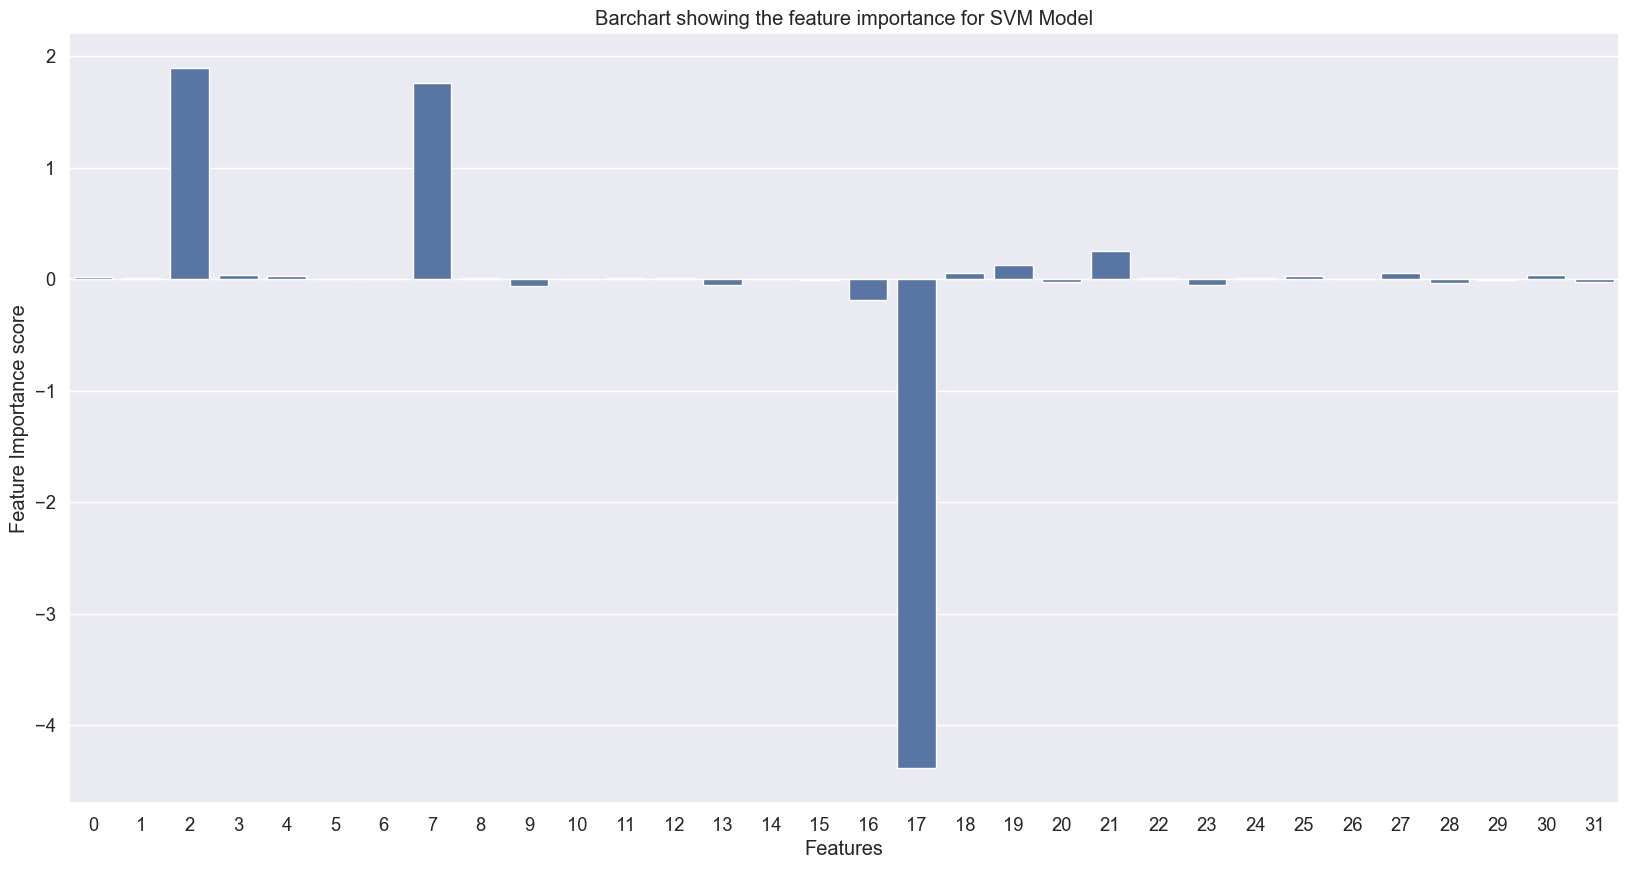

In [265]:
# chart to visualize the feature importance
plt.subplots(figsize=(20, 10))
sns.barplot(x=[X for X in range(len(FeatureImportance))], y=FeatureImportance)
plt.xlabel('Features')
plt.ylabel('Feature Importance score')
plt.title('Barchart showing the feature importance for SVM Model')
plt.show()


In [266]:
#using the new cols as the selected feature
cols =[ 'on thyroxine', 'query on thyroxine',
       'on antithyroid medication', 'thyroid surgery', 'query hypothyroid', 'tumor','TSH measured', 'TSH',
       'T3 measured', 'T3', 'TT4 measured', 'TT4', 'T4U','FTI',
       'referral source_STMW', 'referral source_SVHD','referral source_SVI', 'referral source_other']
X_new= X[cols]
y_new= y

In [267]:
#list(enumerate(hypothyroid_df.columns))

In [268]:
#encoding the new independent variable
X_new = X_new.apply(LabelEncoder().fit_transform)
X_new_array = X_new.to_numpy()

In [269]:
#encoding the new dependent variable
Labelencoder_y_new= LabelEncoder()  
y_new = Labelencoder_y_new.fit_transform(y)

In [270]:
#splitting the dataset 80-20%
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split( X_new_array, y_new, test_size=0.2, random_state=11)
X_new_train.shape

(2940, 18)

In [271]:
#standardize the independent variables of the dataset
st_X= StandardScaler()  
X_svm_train= st_X.fit_transform(X_new_train) 
X_svm_test = st_X.fit_transform(X_new_test)
len(X_new_train), len(y_new_train)

(2940, 2940)

In [272]:
final_classifier = SVC(kernel='linear', random_state=0)  
#training the model using training set
final_classifier.fit(X_svm_train, y_new_train) 

SVC(kernel='linear', random_state=0)

In [273]:
# Predicting and training the Test Result
final_classifier_predict_train_svm = final_classifier.predict(X_svm_train)
final_classifier_predict_test_svm = final_classifier.predict(X_svm_test)

In [274]:
# checking the accuracy score of the test and train set
print('Prediction on training set', accuracy_score(final_classifier_predict_train_svm, y_new_train))
print('Prediction on testing set', accuracy_score(final_classifier_predict_test_svm, y_new_test))

Prediction on training set 0.9863945578231292
Prediction on testing set 0.9904761904761905


### Confusion Matrix

In [275]:
# Creating the confusion matrix
def get_matrix(name, y_mat_test, mat_classifier_predict_test):
    conf_matrix = metrics.confusion_matrix(y_mat_test, mat_classifier_predict_test)
    
    # Assigning columns names

    # Showing the confusion matrix
    # save confusion matrix and slice into four pieces

    TP = conf_matrix[1][1]
    TN = conf_matrix[0][0]
    FP = conf_matrix[0][1]
    FN = conf_matrix[1][0]
    print('True Positives:', TP)
    print('True Negatives:', TN)
    print('False Positives:', FP)
    print('False Negatives:', FN)

    # calculate accuracy
    conf_accuracy = (float (TP+TN) / float(TP + TN + FP + FN))

    # calculate mis-classification
    conf_misclassification = 1- conf_accuracy

    # calculate the recall
    conf_recall = (TP / float(TP + FN))

    # calculate the True Negative Rate
    conf_True_Negative_Rate = (TN / float(TN + FP))

    # calculate precision
    conf_precision = (TN / float(TN + FP))

    # calculate f_1 score
    conf_f1 = 2 * ((conf_precision * conf_recall) / (conf_precision + conf_recall))

    print('-'*50)
    print(f'Accuracy: {round(conf_accuracy,4)}') 
    print(f'Mis-Classification: {round(conf_misclassification,2)}') 
    print(f'Sensitivity: {round(conf_recall,2)}') 
    print(f'Specificity: {round(conf_True_Negative_Rate,2)}') 
    print(f'Precision: {round(conf_precision,2)}')
    print(f'f_1 Score: {round(conf_f1,2)}')
    print('-'*50)
    print(name + ' confusion matrix is:')
    print(conf_matrix)

In [276]:
#conf matrix on feature importance
get_matrix('feature importance', y_new_test, final_classifier_predict_test_svm)

True Positives: 676
True Negatives: 52
False Positives: 5
False Negatives: 2
--------------------------------------------------
Accuracy: 0.9905
Mis-Classification: 0.01
Sensitivity: 1.0
Specificity: 0.91
Precision: 0.91
f_1 Score: 0.95
--------------------------------------------------
feature importance confusion matrix is:
[[ 52   5]
 [  2 676]]


### Univarate feature selection

Feature 0: 0.006287
Feature 1: 9.245346
Feature 2: 19.633047
Feature 3: 1.890490
Feature 4: 1.031709
Feature 5: 0.164140
Feature 6: 3.686680
Feature 7: 1.729407
Feature 8: 0.289018
Feature 9: 29.467948
Feature 10: 0.818815
Feature 11: 0.012788
Feature 12: 2.709931
Feature 13: 0.070160
Feature 14: 0.086448
Feature 15: 5.473782
Feature 16: 20.898817
Feature 17: 681.951792
Feature 18: 1.573382
Feature 19: 103.818778
Feature 20: 6.065907
Feature 21: 278.808888
Feature 22: 0.006030
Feature 23: 1.477757
Feature 24: 0.003315
Feature 25: 320.785576
Feature 26: nan
Feature 27: 0.556259
Feature 28: 13.214054
Feature 29: 0.126184
Feature 30: 5.416318
Feature 31: 0.128384


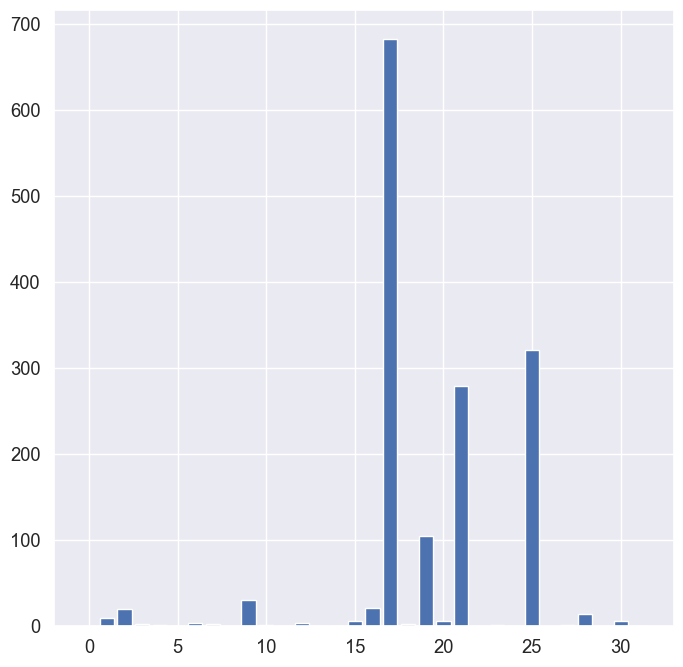

In [277]:
#fitting dataset on univarate selection
test = SelectKBest(score_func=f_classif, k=7)
fit = test.fit(X_train, y_train)
X_train_fit = fit.transform(X_train)
X_test_fit = fit.transform(X_test)

for i in range(len(fit.scores_)):
    print('Feature %d: %f' % (i, fit.scores_[i]))
plt.bar([i for i in range(len(fit.scores_))], fit.scores_)
    
plt.show()

In [278]:
classifier = SVC(kernel='linear', random_state=11)  
#training the model using training set
classifier.fit(X_train_fit, y_train)  

SVC(kernel='linear', random_state=11)

In [279]:
# Predicting and training the Test Result
classifier_predict_train_Uni = classifier.predict(X_train_fit)
classifier_predict_test_Uni= classifier.predict(X_test_fit) 

In [280]:
from sklearn.metrics import accuracy_score
# checking the accuracy score of the test and train set
print('Prediction on training set', accuracy_score(classifier_predict_train_Uni, y_train))
print('Prediction on testing set', accuracy_score(classifier_predict_test_Uni, y_test))

Prediction on training set 0.9642857142857143
Prediction on testing set 0.964625850340136


In [281]:
#conf_matrix on univarate selection
get_matrix('univarate', y_test, classifier_predict_test_Uni)

True Positives: 675
True Negatives: 34
False Positives: 23
False Negatives: 3
--------------------------------------------------
Accuracy: 0.9646
Mis-Classification: 0.04
Sensitivity: 1.0
Specificity: 0.6
Precision: 0.6
f_1 Score: 0.75
--------------------------------------------------
univarate confusion matrix is:
[[ 34  23]
 [  3 675]]


### Recursive feature elimination

Num Features: 16
Selected Features: [False False  True  True False False False  True False  True False False
 False  True False False  True  True  True  True  True  True False  True
  True  True False  True False False  True False]
Feature Ranking: [ 6 10  1  1  2 13 15  1 11  1 14  7  8  1 16  3  1  1  1  1  1  1  4  1
  1  1 17  1  5 12  1  9]
Feature 0: 6.000000
Feature 1: 10.000000
Feature 2: 1.000000
Feature 3: 1.000000
Feature 4: 2.000000
Feature 5: 13.000000
Feature 6: 15.000000
Feature 7: 1.000000
Feature 8: 11.000000
Feature 9: 1.000000
Feature 10: 14.000000
Feature 11: 7.000000
Feature 12: 8.000000
Feature 13: 1.000000
Feature 14: 16.000000
Feature 15: 3.000000
Feature 16: 1.000000
Feature 17: 1.000000
Feature 18: 1.000000
Feature 19: 1.000000
Feature 20: 1.000000
Feature 21: 1.000000
Feature 22: 4.000000
Feature 23: 1.000000
Feature 24: 1.000000
Feature 25: 1.000000
Feature 26: 17.000000
Feature 27: 1.000000
Feature 28: 5.000000
Feature 29: 12.000000
Feature 30: 1.000000
Fea

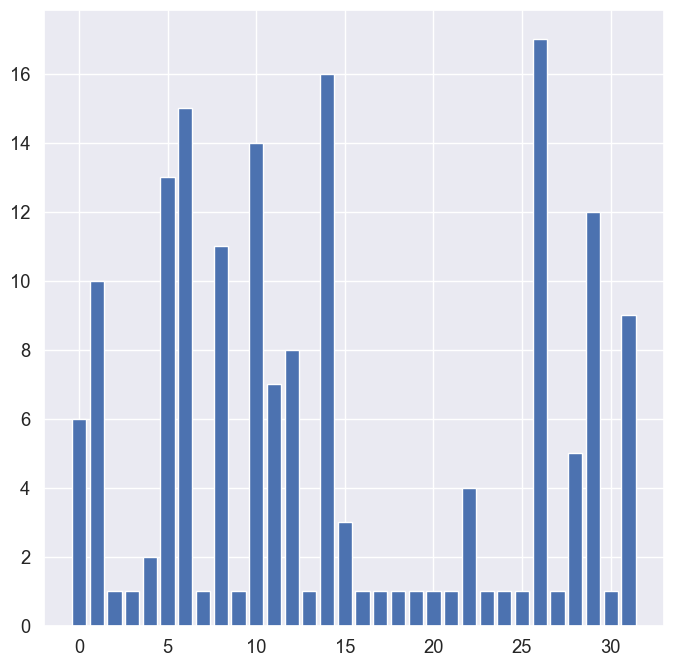

In [282]:
#fitting dataset using RFE

from sklearn.feature_selection import RFE
classifier = SVC(kernel='linear', random_state=11)  
rfe = RFE(classifier)
fit = rfe.fit(X_train,y_train)

#transforming on RFE
X_train_fit_RFE = fit.transform(X_train)
X_test_fit_RFE = fit.transform(X_test)


print("Num Features: %d" % fit.n_features_)
print("Selected Features: %s" % fit.support_)
print("Feature Ranking: %s" % fit.ranking_)
for i in range(len(fit.support_)):
    print('Feature %d: %f' % (i, fit.ranking_[i]))
plt.bar([i for i in range(len(fit.ranking_))], fit.ranking_)
    
plt.show()

In [283]:
classifier = SVC(kernel='linear', random_state=0)  
#training the model using training set
classifier.fit(X_train_fit_RFE, y_train)  

SVC(kernel='linear', random_state=0)

In [284]:
# Predicting and training the Test Result
classifier_predict_train_RFE = classifier.predict(X_train_fit_RFE)
classifier_predict_test_RFE = classifier.predict(X_test_fit_RFE)

In [285]:
# checking the accuracy score of the test and train set
print('Prediction on training set', accuracy_score(classifier_predict_train_RFE, y_train))
print('Prediction on testing set', accuracy_score(classifier_predict_test_RFE, y_test))

Prediction on training set 0.9727891156462585
Prediction on testing set 0.9727891156462585


In [286]:
#Conf matrix on recursive
get_matrix('recursive', y_test, classifier_predict_test_RFE)

True Positives: 677
True Negatives: 38
False Positives: 19
False Negatives: 1
--------------------------------------------------
Accuracy: 0.9728
Mis-Classification: 0.03
Sensitivity: 1.0
Specificity: 0.67
Precision: 0.67
f_1 Score: 0.8
--------------------------------------------------
recursive confusion matrix is:
[[ 38  19]
 [  1 677]]
